# MMA 602 Group Project
# Movie Rating Prediction Analysis (2015-2025)

This notebook explores movie data from 2015 to 2025 to understand what factors influence audience ratings. The goal is to build a predictive model that can help content strategists make informed decisions about which types of movies to produce.

## Table of Contents
1.  **Introduction & Setup**
    *   [Step 1: Load and Merge Movie Data](#step-1-load-and-merge-movie-data)
2.  **Data Preparation**
    *   [Step 2: Initial Data Processing](#step-2-initial-data-processing)
    *   [Step 3: Exploratory Data Analysis (EDA)](#step-3-exploratory-data-analysis-eda)
3.  **Baseline Modeling**
    *   [Step 4: Build a Prediction Pipeline](#step-4-build-a-prediction-pipeline)
    *   [Step 5: Visualize the Decision Tree](#step-5-visualize-the-decision-tree)
    *   [Step 6: Prune the Tree](#step-6-prune-the-tree-to-prevent-overfitting)
4.  **Advanced Modeling**
    *   [Step 7: Random Forest Regression](#step-7-random-forest-regression)
    *   [Step 8: Gradient Boosting with XGBoost](#step-8-gradient-boosting-with-xgboost)
    *   [Step 9: Support Vector Regression (SVR)](#step-9-support-vector-regression-svr)
    *   [Step 10: Linear Regression Analysis](#step-10-addressing-too-many-variables-with-linear-regression)
    *   [Step 10b: Regularized Linear Models (Ridge & Lasso)](#step-10b-regularized-linear-models-ridge--lasso)
5.  **Unsupervised Learning**
    *   [Step 11: Clustering Analysis](#step-11-clustering-analysis)
6.  **Business & Model Evaluation**
    *   [Step 12: Feature Importance](#step-12-model-interpretation--feature-importance)
    *   [Step 13: Business Insights (ROI)](#step-13-business-insights---roi--revenue-analysis)
    *   [Step 14: Final Model Comparison](#step-14-final-model-comparison)
    *   [Step 14b: Feature Selection & Refinement](#step-14b-feature-selection--model-refinement)
    *   [Step 15: The "Greenlight" Tool](#step-15-the-greenlight-tool-managerial-application)
7.  **Conclusion**
    *   [Step 16: Final Conclusion](#step-16-final-conclusion--recommendations)

## Dataset Overview
The dataset contains movie information including genres, cast, ratings, votes, budget, duration, and MPA ratings across 11 years (2015-2025).

In [98]:
# Data manipulation and analysis
import pandas as pd
import numpy as np
import os
import re
import ast

# Visualization
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Machine Learning - Preprocessing
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Machine Learning - Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import LinearRegression
from sklearn import tree

# Machine Learning - Evaluation
from sklearn.metrics import mean_squared_error, r2_score


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

## Import Required Libraries

First, I'll import all the libraries needed for data manipulation, visualization, and machine learning.

In [99]:
# List to hold dataframes
all_dataframes = []

# Iterate through years 2015 to 2025
for year in range(2015, 2026):
    # Construct the file path
    # Assuming the folder structure is ./<year>/merged_movies_data_<year>.csv relative to this notebook
    file_path = os.path.join(str(year), f'merged_movies_data_{year}.csv')
    
    if os.path.exists(file_path):
        print(f"Reading {file_path}...")
        try:
            df = pd.read_csv(file_path)
            all_dataframes.append(df)
        except Exception as e:
            print(f"Error reading {file_path}: {e}")
    else:
        print(f"File not found: {file_path}")

# Concatenate all dataframes
if all_dataframes:
    merged_df = pd.concat(all_dataframes, ignore_index=True)
    print(f"\nSuccessfully merged {len(all_dataframes)} files.")
    print(f"Total rows: {len(merged_df)}")
    
    # Save the merged dataframe
    output_filename = 'merged_movies_2015_2025.csv'
    merged_df.to_csv(output_filename, index=False)
    print(f"Saved merged data to {output_filename}")
    
    # Display first few rows
    display(merged_df.head())
else:
    print("No files were loaded.")

Reading 2015\merged_movies_data_2015.csv...
Reading 2016\merged_movies_data_2016.csv...
Reading 2017\merged_movies_data_2017.csv...
Reading 2018\merged_movies_data_2018.csv...
Reading 2019\merged_movies_data_2019.csv...
Reading 2020\merged_movies_data_2020.csv...
Reading 2021\merged_movies_data_2021.csv...
Reading 2022\merged_movies_data_2022.csv...
Reading 2023\merged_movies_data_2023.csv...
Reading 2024\merged_movies_data_2024.csv...
Reading 2025\merged_movies_data_2025.csv...

Successfully merged 11 files.
Total rows: 6600
Saved merged data to merged_movies_2015_2025.csv


,Title,Year,Duration,MPA,Rating,Votes,méta_score,description,Movie Link,writers,...,opening_weekend_Gross,grossWorldWWide,gross_US_Canada,release_date,countries_origin,filming_locations,production_company,awards_content,genres,Languages
0,1. Star Wars: Episode VII - The Force Awakens,2015,2h 18m,PG-13,7.8,996K,80.0,"As a new threat to the galaxy rises, Rey, a de...",https://www.imdb.com/title/tt2488496/?ref_=sr_i_1,"['Lawrence Kasdan', 'J.J. Abrams', 'Michael Ar...",...,"$247,966,675","$2,071,310,218","$936,662,225","December 18, 2015","['United States', 'United Kingdom']","['Skellig Michael, County Kerry, Ireland (fina...","['Lucasfilm', 'Bad Robot']","Nominated for 5 Oscars, 64 wins & 140 nominati...","['Action Epic', 'Adventure Epic', 'Globetrotti...",['English']
1,2. Jurassic World,2015,2h 4m,PG-13,6.9,699K,59.0,"A new theme park, built on the original site o...",https://www.imdb.com/title/tt0369610/?ref_=sr_i_2,"['Rick Jaffa', 'Amanda Silver', 'Colin Trevorr...",...,"$208,806,270","$1,671,537,444","$653,406,625","June 12, 2015","['United States', 'Canada']","[""Kualoa Ranch - 49560 Kamehameha Highway, Ka'...","['Universal Pictures', 'Amblin Entertainment',...","Awards, 15 wins & 58 nominations total","['Dinosaur Adventure', 'Jungle Adventure', 'Ac...",['English']
2,3. Avengers: Age of Ultron,2015,2h 21m,PG-13,7.3,955K,66.0,When Tony Stark and Bruce Banner try to jump-s...,https://www.imdb.com/title/tt2395427/?ref_=sr_i_3,"['Joss Whedon', 'Stan Lee', 'Jack Kirby']",...,"$191,271,109","$1,405,018,048","$459,005,868","May 1, 2015",['United States'],"['Chittagong, Bangladesh (Shipyard scene)']",['Marvel Studios'],"Awards, 8 wins & 52 nominations total","['Artificial Intelligence', 'Superhero', 'Urba...","['English', 'Korean']"
3,4. Inside Out,2015,1h 35m,PG,8.1,860K,94.0,After young Riley is uprooted from her Midwest...,https://www.imdb.com/title/tt2096673/?ref_=sr_i_4,"['Pete Docter', 'Ronnie Del Carmen', 'Meg LeFa...",...,"$90,440,272","$859,076,254","$356,461,711","June 19, 2015",['United States'],"['Pixar Animation Studios - 1200 Park Avenue, ...","['Pixar Animation Studios', 'Walt Disney Pictu...","Won 1 Oscar, 99 wins & 118 nominations total","['Coming-of-Age', 'Computer Animation', 'Adven...","['English', 'Portuguese', 'Latvian']"
4,5. Furious 7,2015,2h 17m,PG-13,7.1,426K,67.0,Deckard Shaw seeks revenge against Dominic Tor...,https://www.imdb.com/title/tt2820852/?ref_=sr_i_5,"['Chris Morgan', 'Gary Scott Thompson']",...,"$147,187,040","$1,515,342,457","$353,007,020","April 3, 2015","['United States', 'China', 'Japan', 'Canada', ...","['Abu Dhabi, United Arab Emirates']","['Universal Pictures', 'Media Rights Capital (...","Awards, 36 wins & 36 nominations total","['Car Action', 'Action', 'Thriller']","['English', 'Thai', 'Arabic', 'Spanish']"


## STEP 1: Load and Merge Movie Data

The first step is to load movie data from multiple years (2015-2025) and combine them into a single dataframe for analysis. Each year's data is stored in a separate folder with CSV files.

In [100]:
# change the "méta_score" column to "meta_score"
merged_df_2 = merged_df.rename(columns={'méta_score': 'meta_score'}, inplace=False)
# Drop columns not relevant to the analysis of Genre, Age Group, Runtime, and Creative Teams vs Audience Ratings
cols_to_drop = [
    'description', 
    'Movie Link', 
    'release_date', 
    'awards_content', 
    'filming_locations', 
    'countries_origin', 
    'Languages', 
    'production_company'
]
filtered_df = merged_df_2.drop(columns=cols_to_drop, errors='ignore')
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6600 entries, 0 to 6599
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Title                  6600 non-null   object 
 1   Year                   6600 non-null   int64  
 2   Duration               6431 non-null   object 
 3   MPA                    4670 non-null   object 
 4   Rating                 6343 non-null   float64
 5   Votes                  6343 non-null   object 
 6   meta_score             4302 non-null   float64
 7   writers                6600 non-null   object 
 8   directors              6600 non-null   object 
 9   stars                  6485 non-null   object 
 10  budget                 2209 non-null   object 
 11  opening_weekend_Gross  4551 non-null   object 
 12  grossWorldWWide        5526 non-null   object 
 13  gross_US_Canada        4954 non-null   object 
 14  genres                 6600 non-null   object 
dtypes: f

## STEP 2: Initial Data Processing


### Missing Data Handling Plan

Based on the goal of analyzing audience reception (`Rating`), here is my strategy for handling missing data:

1.  **`Rating` & `Votes` (Target Variables):** Since these are our primary outcome metrics, we cannot analyze shows that don't have them.
    *   **Action:** Drop rows where `Rating` or `Votes` is missing.

2.  **`MPA` (Target Age Group):** This is a key feature for the strategy ("target age group"). Missing values likely mean the content wasn't rated or the data is missing.
    *   **Action:** Fill missing values with `'Unrated'` to keep the data but acknowledge the missing category.

3.  **`Duration` (Runtime):** This is another key feature.
    *   **Action:** First, clean the column (convert "90 min" to number). Then, fill missing values with the **median** duration, which is robust to outliers.

4.  **`budget` & Gross Revenue:** These have high missingness (e.g., Budget missing ~66%).
    *   **Action:** Do **not** drop rows based on these, or we'll lose too much data. We will keep them as `NaN` (Not a Number) for now. If we do a specific ROI analysis later, we can filter for just the rows that have this data.

5.  **`meta_score`:**
    *   **Action:** Keep as is. It's useful for comparison but not the primary target.

6.  **`stars`:**
    *   **Action:** Fill with `'Unknown'`.

In [101]:
# Function to parse duration (e.g., "2h 18m", "1h 30m", "45m")
def parse_duration(duration_str):
    if pd.isna(duration_str):
        return None
    duration_str = str(duration_str).lower()
    hours = 0
    minutes = 0
    
    # Extract hours
    h_match = re.search(r'(\d+)h', duration_str)
    if h_match:
        hours = int(h_match.group(1))
        
    # Extract minutes
    m_match = re.search(r'(\d+)m', duration_str)
    if m_match:
        minutes = int(m_match.group(1))
        
    total_minutes = hours * 60 + minutes
    return total_minutes if total_minutes > 0 else None

# Function to parse votes (e.g., "996K", "1.2M", "500")
def parse_votes(votes_str):
    if pd.isna(votes_str):
        return None
    votes_str = str(votes_str).upper().replace(',', '')
    
    if 'K' in votes_str:
        return float(votes_str.replace('K', '')) * 1000
    elif 'M' in votes_str:
        return float(votes_str.replace('M', '')) * 1000000
    else:
        try:
            return float(votes_str)
        except ValueError:
            return None

# Create a copy for cleaning
filtered_df_2 = filtered_df.copy()

# 1. Drop rows where Rating or Votes are missing
filtered_df_2 = filtered_df_2.dropna(subset=['Rating', 'Votes'])

# 2. Fill missing MPA with 'Unrated'
filtered_df_2['MPA'] = filtered_df_2['MPA'].fillna('Unrated')

# 3. Clean and Fill Duration
filtered_df_2['Duration'] = filtered_df_2['Duration'].apply(parse_duration)
# Fill missing Duration with the median
median_duration = filtered_df_2['Duration'].median()
filtered_df_2['Duration'] = filtered_df_2['Duration'].fillna(median_duration)

# 4. Fill missing Stars with 'Unknown'
filtered_df_2['stars'] = filtered_df_2['stars'].fillna('Unknown')

# 5. Clean Votes
filtered_df_2['Votes'] = filtered_df_2['Votes'].apply(parse_votes)

# Check the info again to see the improvement
print("Missing values after cleaning (filtered_df_2):")
print(filtered_df_2.isnull().sum())
print("\nNew Shape:", filtered_df_2.shape)
print("\nSample Data:")
display(filtered_df_2[['Duration', 'Votes']].head())

Missing values after cleaning (filtered_df_2):
Title                       0
Year                        0
Duration                    0
MPA                         0
Rating                      0
Votes                       0
meta_score               2043
writers                     0
directors                   0
stars                       0
budget                   4162
opening_weekend_Gross    1818
grossWorldWWide           854
gross_US_Canada          1426
genres                      0
dtype: int64

New Shape: (6343, 15)

Sample Data:


,Duration,Votes
0,138.0,996000.0
1,124.0,699000.0
2,141.0,955000.0
3,95.0,860000.0
4,137.0,426000.0


In [102]:
# Exploratory Data Analysis (EDA)
#Summary statistics
eda_summary = filtered_df_2.describe(include='all')
print("Summary Statistics:")
display(eda_summary)


Summary Statistics:


,Title,Year,Duration,MPA,Rating,Votes,meta_score,writers,directors,stars,budget,opening_weekend_Gross,grossWorldWWide,gross_US_Canada,genres
count,6343,6343.000000,6343.000000,6343,6343.000000,6.343000e+03,4300.000000,6343,6343,6343,2181,4525,5489,4917,6343
unique,6343,NaN,NaN,17,NaN,NaN,NaN,5896,4747,6257,636,4436,5474,4893,2692
top,1. Star Wars: Episode VII - The Force Awakens,NaN,NaN,Unrated,NaN,NaN,NaN,[],['Tyler Perry'],Unknown,"$20,000,000 (estimated)","$3,270","$600,549","$600,549",['Drama']
freq,1,NaN,NaN,1893,NaN,NaN,NaN,54,10,80,72,4,3,3,468
mean,NaN,2019.831783,106.915497,NaN,6.351537,3.808080e+04,61.682558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,3.082015,20.462689,NaN,1.100371,1.013952e+05,16.087482,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,2015.000000,44.000000,NaN,1.500000,5.000000e+00,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,2017.000000,93.000000,NaN,5.700000,9.365000e+02,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,2020.000000,103.000000,NaN,6.500000,5.100000e+03,64.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,2022.000000,117.000000,NaN,7.100000,2.600000e+04,74.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## STEP 3: Exploratory Data Analysis (EDA)

In [103]:
#Look at the data type for each variable
data_types = filtered_df_2.dtypes
print("Data Types:")
display(data_types)


Data Types:


Title                     object
Year                       int64
Duration                 float64
MPA                       object
Rating                   float64
Votes                    float64
meta_score               float64
writers                   object
directors                 object
stars                     object
budget                    object
opening_weekend_Gross     object
grossWorldWWide           object
gross_US_Canada           object
genres                    object
dtype: object

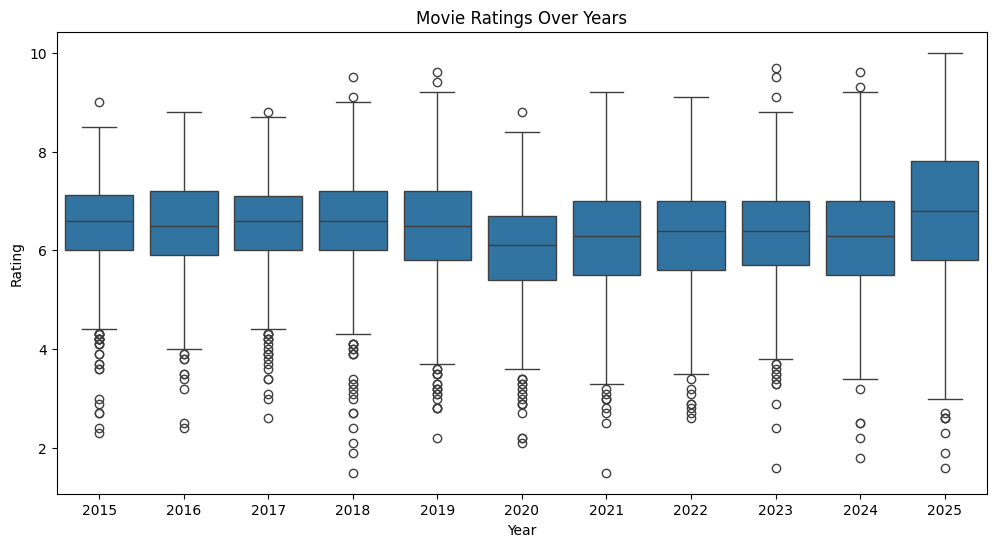

In [104]:
# Rating over Year
plt.figure(figsize=(12, 6))
sns.boxplot(x='Year', y='Rating', data=filtered_df_2)
# The ratings have remained relatively stable over the years, with a slight increase in median ratings in recent years.
plt.title('Movie Ratings Over Years')
plt.show()

# Drop all movies with concert genre
filtered_df_2 = filtered_df_2[~filtered_df_2['genres'].str.contains('Concert', case=False, na=False)]

Visual exploration helps identify trends and outliers that summary statistics might miss.

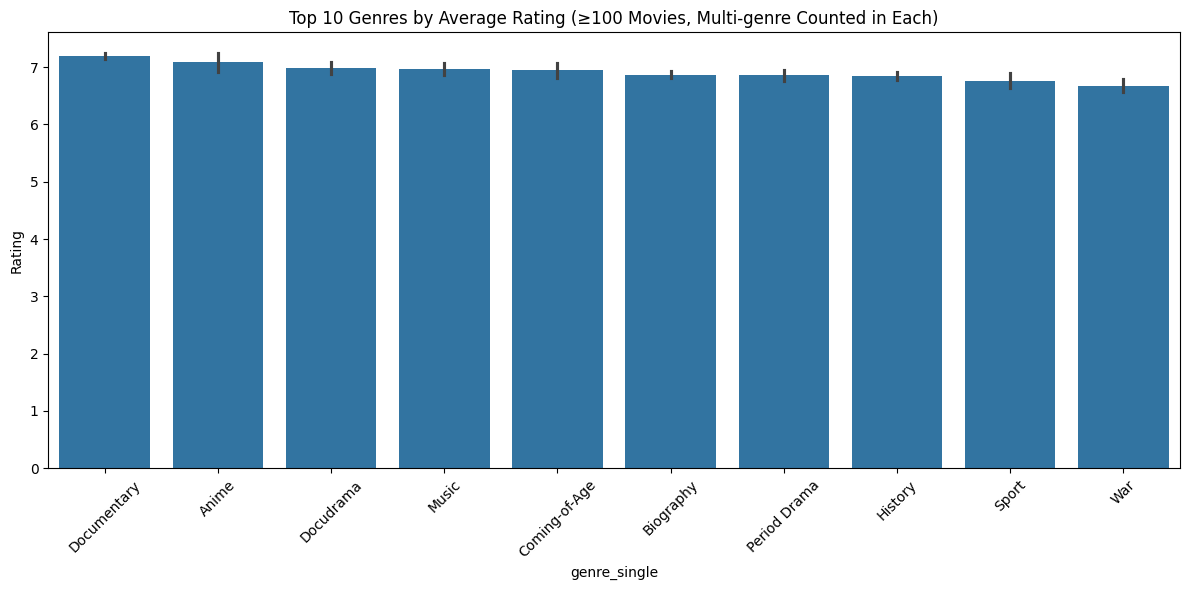

In [105]:
# Genres vs Rating barplot of top ten genres and order by average rating, handling multi-genre movies

# Parse the genres column (stored as a string representation of a Python list) into actual lists
def parse_genres(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        # Fallback: treat as comma-separated string
        return [g.strip() for g in str(x).split(',') if g.strip()]

# Create a list column and explode so each row has a single genre
filtered_df_2['genres_list'] = filtered_df_2['genres'].apply(parse_genres)
genres_exploded = filtered_df_2.explode('genres_list').rename(columns={'genres_list': 'genre_single'})

# Drop empty genres just in case
genres_exploded = genres_exploded[genres_exploded['genre_single'].notna() & (genres_exploded['genre_single'] != '')]

# ---- Filter to genres that have at least 100 movies ----
genre_counts = genres_exploded['genre_single'].value_counts()
valid_genres = genre_counts[genre_counts >= 100].index
genres_exploded_100 = genres_exploded[genres_exploded['genre_single'].isin(valid_genres)]

# Group by average rating on the filtered exploded data
top_genres = (
    genres_exploded_100.groupby('genre_single')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='genre_single',
    y='Rating',
    data=genres_exploded_100[genres_exploded_100['genre_single'].isin(top_genres)],
    order=top_genres
)
plt.title('Top 10 Genres by Average Rating (≥100 Movies, Multi-genre Counted in Each)')
# x axis labels rotation for better readability
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Genre Analysis

Movies often belong to multiple genres. To properly analyze genre impact on ratings, we exploded the genre list so each movie-genre combination becomes a separate row. This allows accurate genre-wise average calculations.

In [106]:
# Count how many movies belong to each genre (using exploded data)

genre_counts = genres_exploded['genre_single'].value_counts().reset_index()

genre_counts.columns = ['genre', 'movie_count']



print('Number of movies per genre (top 20):')

display(genre_counts.head)

Number of movies per genre (top 20):


<bound method NDFrame.head of                   genre  movie_count
0                 Drama         3395
1                Comedy         1728
2              Thriller         1630
3                Action         1200
4               Romance          900
..                  ...          ...
177          Reality TV            1
178  Travel Documentary            1
179           Iyashikei            1
180              Sitcom            1
181              Giallo            1

[182 rows x 2 columns]>

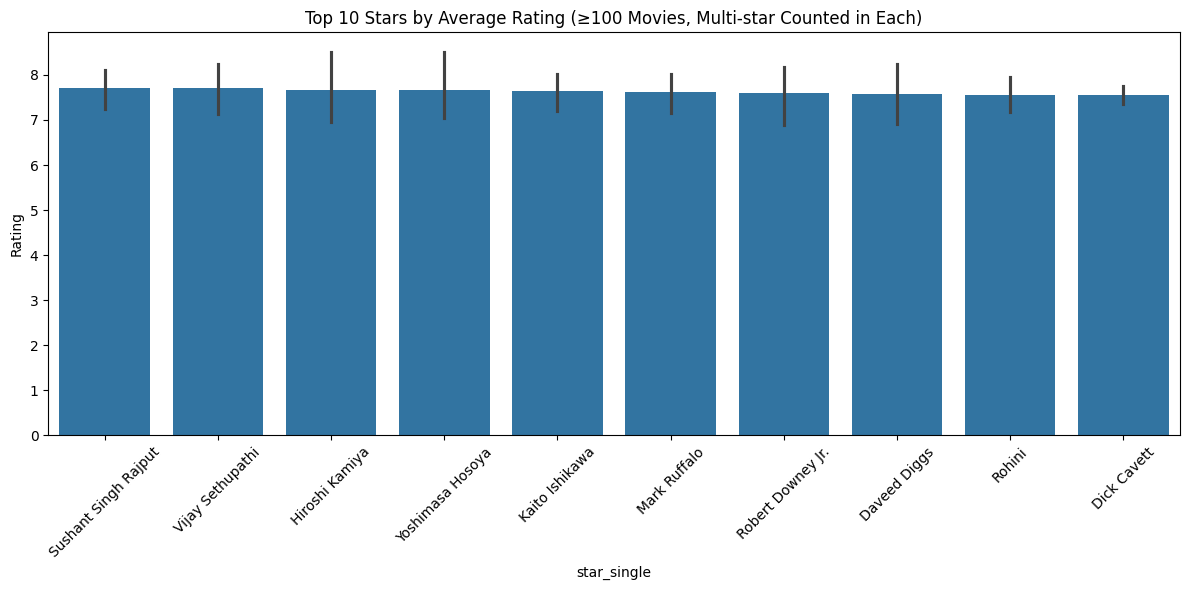

In [107]:
# Stars vs Rating barplot of top ten stars (actors) with at least 100 movies, handling multi-star movies

# Parse the stars column (stored as a string representation of a Python list) into actual lists
def parse_stars(x):
    if pd.isna(x):
        return []
    try:
        return ast.literal_eval(x)
    except (ValueError, SyntaxError):
        # Fallback: treat as comma-separated string
        return [s.strip() for s in str(x).split(',') if s.strip()]

# Create a list column and explode so each row has a single star
filtered_df_2['stars_list'] = filtered_df_2['stars'].apply(parse_stars)
stars_exploded = filtered_df_2.explode('stars_list').rename(columns={'stars_list': 'star_single'})

# Drop empty stars just in case
stars_exploded = stars_exploded[stars_exploded['star_single'].notna() & (stars_exploded['star_single'] != '')]

# ---- Filter to stars that have appeared in at least 100 movies ----
star_counts = stars_exploded['star_single'].value_counts()
valid_stars = star_counts[star_counts >= 5].index
stars_exploded_100 = stars_exploded[stars_exploded['star_single'].isin(valid_stars)]

# Group by average rating on the filtered exploded data
top_stars = (
    stars_exploded_100.groupby('star_single')['Rating']
    .mean()
    .sort_values(ascending=False)
    .head(10)
    .index
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='star_single',
    y='Rating',
    data=stars_exploded_100[stars_exploded_100['star_single'].isin(top_stars)],
    order=top_stars
)
plt.title('Top 10 Stars by Average Rating (≥100 Movies, Multi-star Counted in Each)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Cast Analysis

Similar to genres, movies have multiple stars. Analyzing star performance requires the same explosion technique to properly calculate which actors appear in highly-rated films.

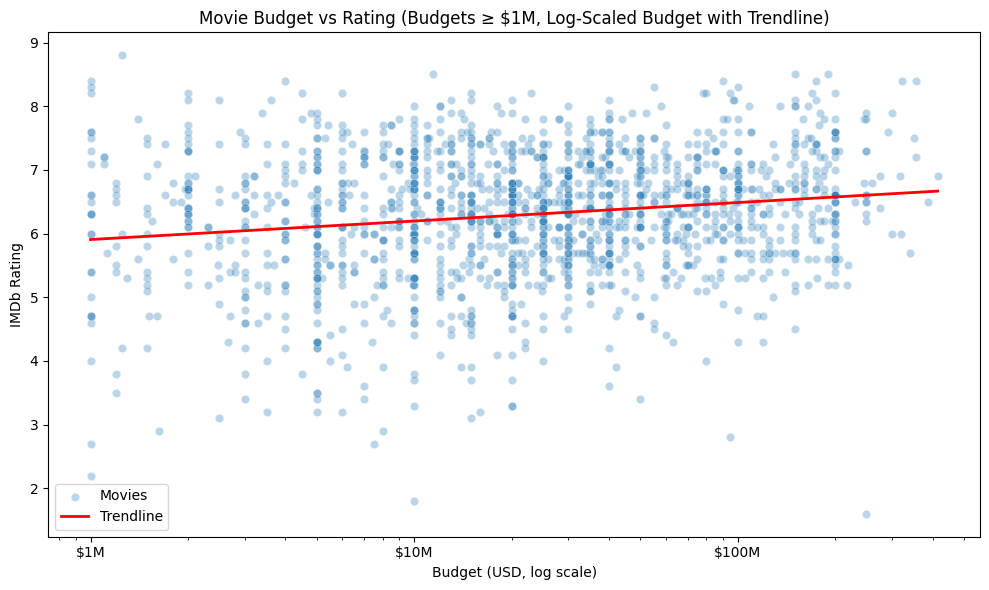

In [108]:
# Scatterplot of Budget vs Rating (log-scaled budget axis with trendline)

# Helper to parse budget strings like "$245,000,000 (estimated)" into numeric USD
def parse_budget(budget_str):
    if pd.isna(budget_str):
        return np.nan
    s = str(budget_str)
    # Keep only the numeric part before any parentheses, e.g. "(estimated)"
    s = s.split('(')[0].strip()
    s = s.replace('$', '').replace(',', '').strip()
    if not s:
        return np.nan
    try:
        return float(s)
    except ValueError:
        return np.nan

# Create numeric budget column
filtered_df_2['budget_numeric'] = filtered_df_2['budget'].apply(parse_budget)

# Drop rows with missing budget and budgets below $1M
budget_rating_df = filtered_df_2.dropna(subset=['budget_numeric', 'Rating'])
budget_rating_df = budget_rating_df[budget_rating_df['budget_numeric'] >= 1_000_000]

# Prepare data for log-linear regression: log10(budget) vs Rating
X = np.log10(budget_rating_df['budget_numeric'].values).reshape(-1, 1)
y = budget_rating_df['Rating'].values

model = LinearRegression()
model.fit(X, y)

# Create a smooth range of budgets for the trendline
budget_range = np.linspace(budget_rating_df['budget_numeric'].min(), budget_rating_df['budget_numeric'].max(), 200)
X_line = np.log10(budget_range).reshape(-1, 1)
y_line = model.predict(X_line)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='budget_numeric',
    y='Rating',
    data=budget_rating_df,
    alpha=0.3,
    label='Movies'
)

# Plot trendline on the same log-scaled x-axis
plt.plot(budget_range, y_line, color='red', linewidth=2, label='Trendline')

# Use log scale on x-axis and format in millions of dollars
ax = plt.gca()
ax.set_xscale('log')
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, pos: f'${x/1_000_000:.0f}M'))

plt.title('Movie Budget vs Rating (Budgets ≥ $1M, Log-Scaled Budget with Trendline)')
plt.xlabel('Budget (USD, log scale)')
plt.ylabel('IMDb Rating')
plt.legend()
plt.tight_layout()
plt.show()

### Budget Impact


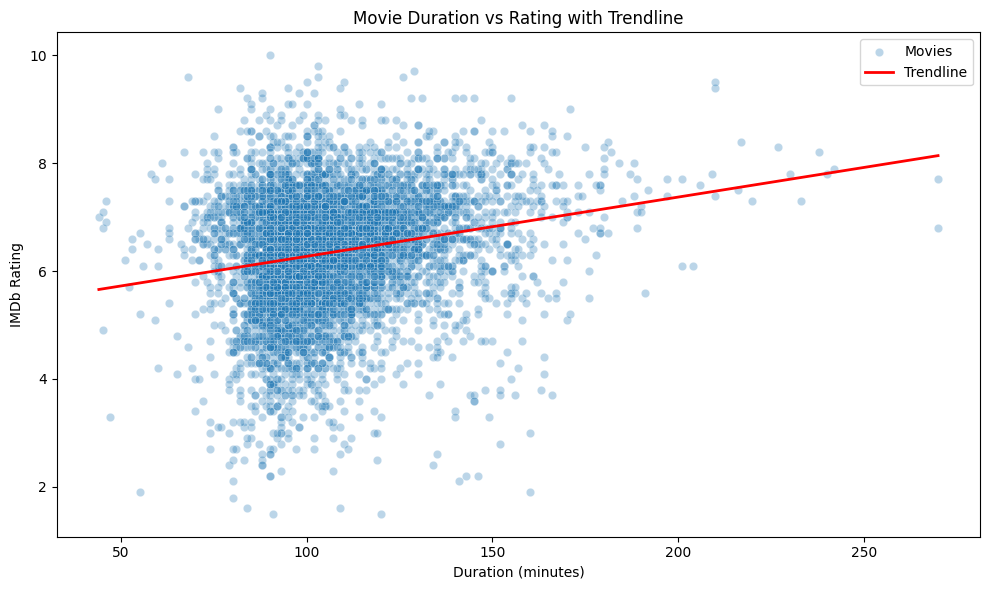

In [109]:
# Scatterplot of Duration vs Rating with trendline

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Duration',
    y='Rating',
    data=filtered_df_2,
    alpha=0.3,
    label='Movies'
)

# Prepare data for linear regression: Duration vs Rating
X_dur = filtered_df_2['Duration'].values.reshape(-1, 1)
y_dur = filtered_df_2['Rating'].values

dur_model = LinearRegression()
dur_model.fit(X_dur, y_dur)

# Create smooth range for duration for the trendline
dur_range = np.linspace(filtered_df_2['Duration'].min(), filtered_df_2['Duration'].max(), 200).reshape(-1, 1)
rating_line = dur_model.predict(dur_range)

plt.plot(dur_range, rating_line, color='red', linewidth=2, label='Trendline')

plt.title('Movie Duration vs Rating with Trendline')
plt.xlabel('Duration (minutes)')
plt.ylabel('IMDb Rating')
plt.legend()
plt.tight_layout()
plt.show()

### Runtime Impact


In [110]:
# Feature Engineering: Extract the first genre as the primary genre
def get_primary_genre(x):
    try:
        genres = ast.literal_eval(x)
        return genres[0] if genres else 'Unknown'
    except:
        return 'Unknown'

# Create a working copy and add primary_genre feature
ml_df = filtered_df_2.copy()
ml_df['primary_genre'] = ml_df['genres'].apply(get_primary_genre)

# Make sure budget_numeric exists from earlier analysis
if 'budget_numeric' not in ml_df.columns:
     def parse_budget(budget_str):
        if pd.isna(budget_str): return np.nan
        s = str(budget_str).split('(')[0].strip().replace('$', '').replace(',', '')
        try: return float(s)
        except: return np.nan
     ml_df['budget_numeric'] = ml_df['budget'].apply(parse_budget)

# Define which columns to use as features and which is the target
NUMERIC_FEATURES = ['Duration', 'Votes', 'budget_numeric', 'meta_score']
CATEGORICAL_FEATURES = ['MPA', 'primary_genre']
TARGET = 'Rating'

# Drop any rows missing the target
ml_df = ml_df.dropna(subset=[TARGET])

X = ml_df[NUMERIC_FEATURES + CATEGORICAL_FEATURES]
y = ml_df[TARGET]

# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Build preprocessing pipelines for numeric and categorical features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine into a single preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ])

# Create the full pipeline: preprocessing + model
dt_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', DecisionTreeRegressor(random_state=42))
])

# Use GridSearchCV to find the best hyperparameters
param_grid = {
    'regressor__max_depth': [5, 10, 15, 20, None],
    'regressor__min_samples_split': [2, 10, 20],
    'regressor__min_samples_leaf': [1, 5, 10]
}

print("Tuning Decision Tree model (this may take a moment)...")
grid_search = GridSearchCV(dt_pipeline, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
grid_search.fit(X_train, y_train)

# Extract the best model and evaluate it
best_model = grid_search.best_estimator_
print(f"\nBest Parameters: {grid_search.best_params_}")

y_pred = best_model.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"\nModel Evaluation (Test Set):")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Tuning Decision Tree model (this may take a moment)...

Best Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_leaf': 10, 'regressor__min_samples_split': 2}

Model Evaluation (Test Set):
RMSE: 0.8874
R² Score: 0.3264


## STEP 4: Build a Prediction Pipeline
### Feature Engineering Strategy

We extract the primary genre from each movie's genre list and use it as a categorical feature along with numeric features like Duration, Votes, Budget, and Meta Score.

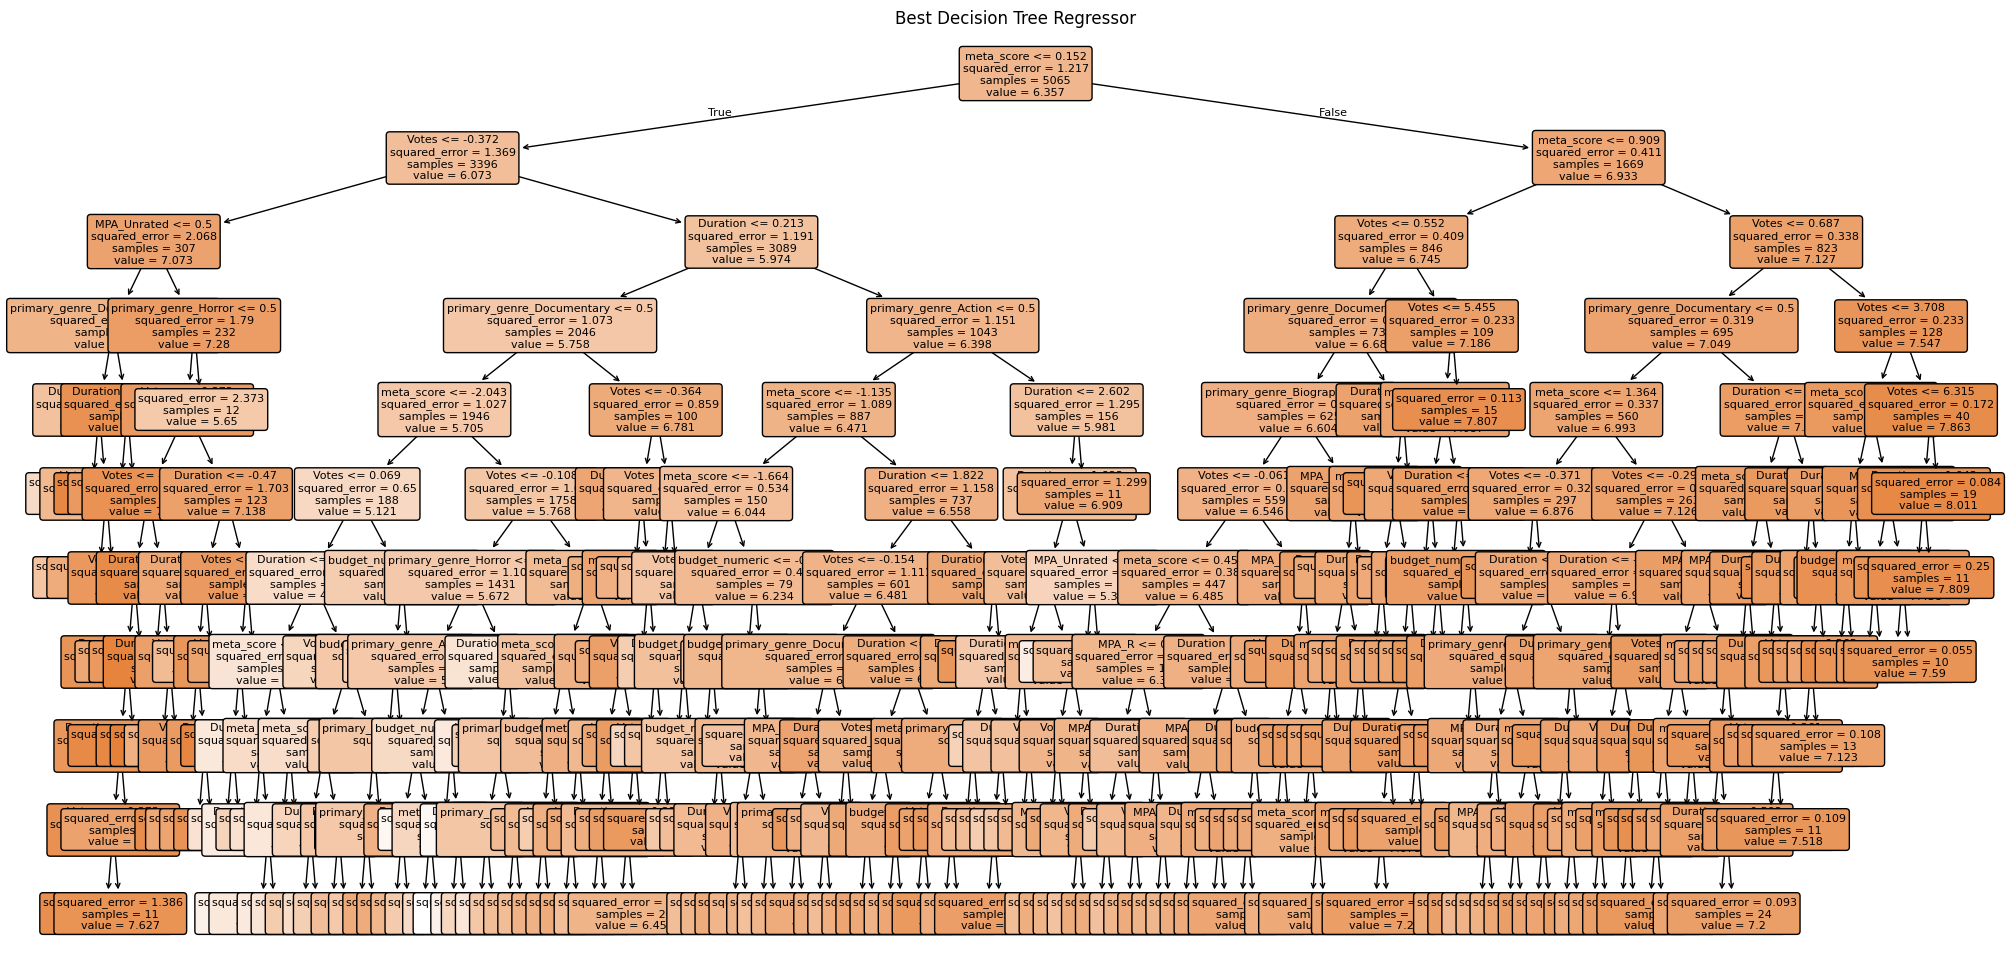

In [111]:
# Visualize the best Decision Tree from the pipeline

# Extract the trained tree from the best pipeline
best_tree = best_model.named_steps['regressor']

# Get feature names after preprocessing
# Numeric features first, then the one-hot encoded categorical features
numeric_names = NUMERIC_FEATURES

ohe = best_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)

feature_names = list(numeric_names) + list(ohe_feature_names)

# Plot the tree
plt.figure(figsize=(24, 12))
tree.plot_tree(
    best_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title('Best Decision Tree Regressor')
plt.show()

## STEP 5: Visualize the Decision Tree

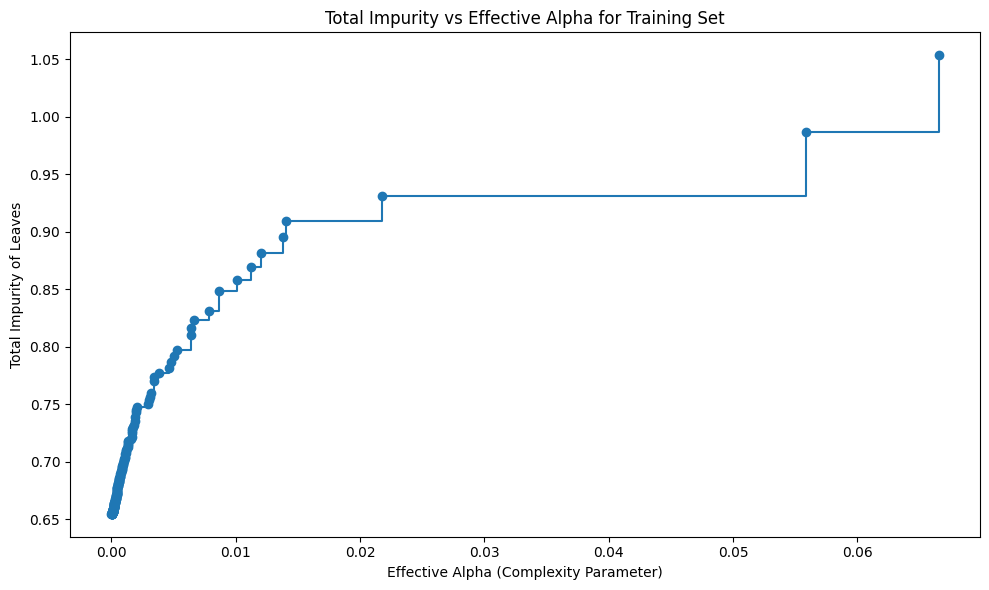

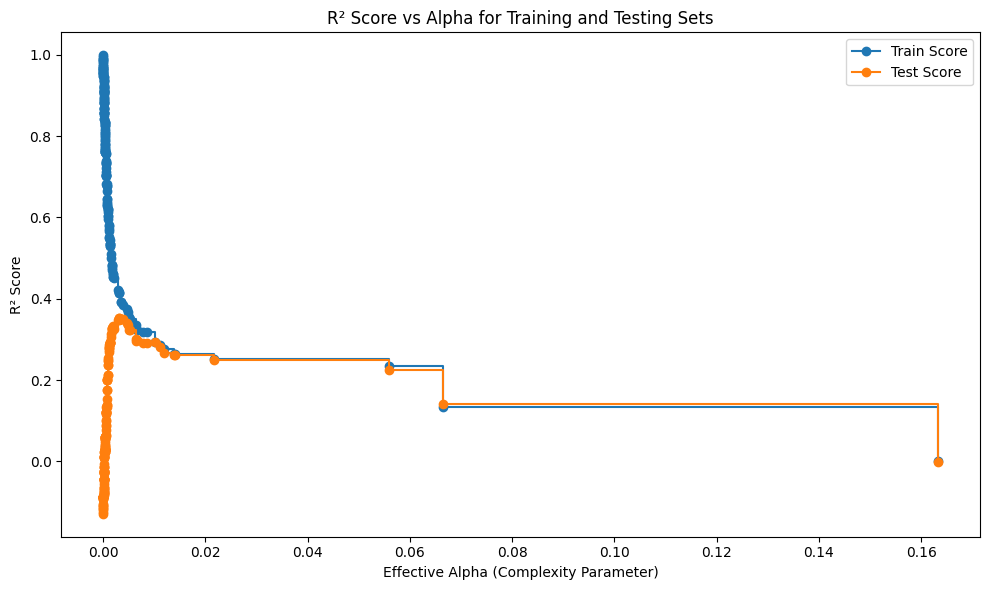


Optimal Alpha (best test score): 0.003116
Selected Alpha (more aggressive pruning): 0.004669
Original Tree Test R²: 0.3264
Pruned Tree Test R²: 0.3415
Original Tree Nodes: 399
Pruned Tree Nodes: 47

Pruned Model Evaluation:
Training Set   - RMSE: 0.8725, R² Score: 0.3742
Test Set       - RMSE: 0.8774, R² Score: 0.3415


In [112]:
# Apply Cost Complexity Pruning to reduce overfitting

# Get the pruning path from the trained tree
best_tree = best_model.named_steps['regressor']
path = best_tree.cost_complexity_pruning_path(
    best_model.named_steps['preprocessor'].transform(X_train), 
    y_train
)
ccp_alphas = path.ccp_alphas
impurities = path.impurities

# Plot how impurity changes with alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas[:-1], impurities[:-1], marker='o', drawstyle="steps-post")
ax.set_xlabel("Effective Alpha (Complexity Parameter)")
ax.set_ylabel("Total Impurity of Leaves")
ax.set_title("Total Impurity vs Effective Alpha for Training Set")
plt.tight_layout()
plt.show()

# Train a tree for each alpha value to find the best one
clfs = []
train_scores = []
test_scores = []

for ccp_alpha in ccp_alphas:
    # Build a pipeline with this specific alpha
    pruned_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', DecisionTreeRegressor(random_state=42, ccp_alpha=ccp_alpha))
    ])
    pruned_pipeline.fit(X_train, y_train)
    clfs.append(pruned_pipeline)
    train_scores.append(pruned_pipeline.score(X_train, y_train))
    test_scores.append(pruned_pipeline.score(X_test, y_test))

# Plot how accuracy changes with alpha
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(ccp_alphas, train_scores, marker='o', label="Train Score", drawstyle="steps-post")
ax.plot(ccp_alphas, test_scores, marker='o', label="Test Score", drawstyle="steps-post")
ax.set_xlabel("Effective Alpha (Complexity Parameter)")
ax.set_ylabel("R² Score")
ax.set_title("R² Score vs Alpha for Training and Testing Sets")
ax.legend()
plt.tight_layout()
plt.show()

# Select the alpha that gives the best test score
best_alpha_idx = np.argmax(test_scores)
optimal_alpha = ccp_alphas[best_alpha_idx]

# For more aggressive pruning, let's use a higher alpha
# Find alphas that give test scores within 5% of the best score
best_test_score = test_scores[best_alpha_idx]
threshold = best_test_score * 0.95  # 95% of best score

# Get the highest alpha that still gives good performance
valid_alphas = [(alpha, score, idx) for idx, (alpha, score) in enumerate(zip(ccp_alphas, test_scores)) if score >= threshold]
if valid_alphas:
    # Pick the highest alpha (most pruning) that meets threshold
    best_alpha = max(valid_alphas, key=lambda x: x[0])[0]
    best_alpha_idx = max(valid_alphas, key=lambda x: x[0])[2]
else:
    best_alpha = optimal_alpha

best_pruned_model = clfs[best_alpha_idx]

print(f"\nOptimal Alpha (best test score): {optimal_alpha:.6f}")
print(f"Selected Alpha (more aggressive pruning): {best_alpha:.6f}")
print(f"Original Tree Test R²: {r2:.4f}")
print(f"Pruned Tree Test R²: {test_scores[best_alpha_idx]:.4f}")
print(f"Original Tree Nodes: {best_tree.tree_.node_count}")
print(f"Pruned Tree Nodes: {best_pruned_model.named_steps['regressor'].tree_.node_count}")

# Evaluate the pruned model on both training and test sets
y_pred_pruned_train = best_pruned_model.predict(X_train)
y_pred_pruned_test = best_pruned_model.predict(X_test)

rmse_pruned_train = np.sqrt(mean_squared_error(y_train, y_pred_pruned_train))
r2_pruned_train = r2_score(y_train, y_pred_pruned_train)

rmse_pruned_test = np.sqrt(mean_squared_error(y_test, y_pred_pruned_test))
r2_pruned_test = r2_score(y_test, y_pred_pruned_test)

print(f"\nPruned Model Evaluation:")
print(f"Training Set   - RMSE: {rmse_pruned_train:.4f}, R² Score: {r2_pruned_train:.4f}")
print(f"Test Set       - RMSE: {rmse_pruned_test:.4f}, R² Score: {r2_pruned_test:.4f}")

## STEP 6: Prune the Tree to Prevent Overfitting


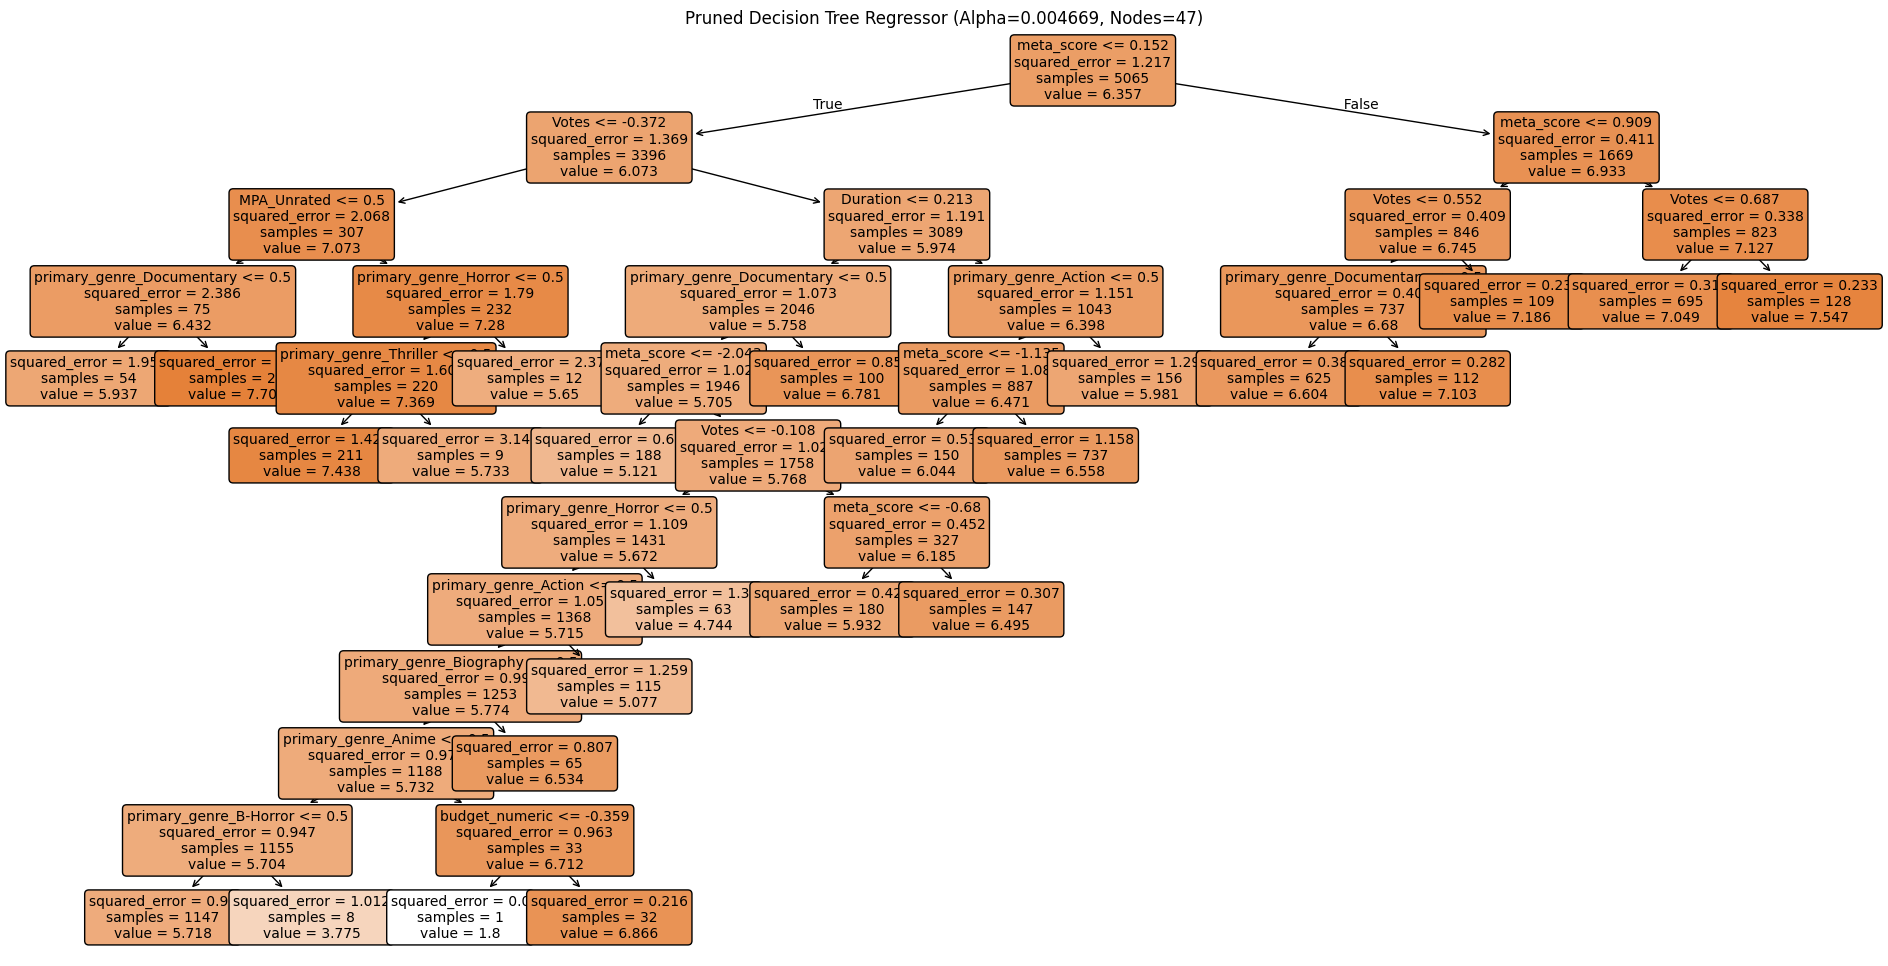

In [113]:
# Visualize the pruned Decision Tree

# Extract the pruned tree
pruned_tree = best_pruned_model.named_steps['regressor']

# Get feature names (same as before)
numeric_names = NUMERIC_FEATURES
ohe = best_pruned_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(numeric_names) + list(ohe_feature_names)

# Plot the pruned tree
plt.figure(figsize=(24, 12))
tree.plot_tree(
    pruned_tree,
    feature_names=feature_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title(f'Pruned Decision Tree Regressor (Alpha={best_alpha:.6f}, Nodes={pruned_tree.tree_.node_count})')
plt.show()

In [114]:
# Test rating prediction for a sample movie
sample_movie = {
    'Duration': 130,          # in minutes
    'Votes': 500000,         # number of votes
    'budget_numeric': 150000000,  # budget in USD
    'meta_score': 75,        # metascore
    'MPA': 'PG-13',          # MPA rating
    'primary_genre': 'Action' # primary genre
}
sample_df = pd.DataFrame([sample_movie])
predicted_rating = best_pruned_model.predict(sample_df)
print(f"\nPredicted Rating for Sample Movie: {predicted_rating[0]:.2f}")


Predicted Rating for Sample Movie: 7.55


In [115]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest Pipeline
# We use the same preprocessor as before
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

print("Training Random Forest model...")
rf_pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred_rf = rf_pipeline.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"\nRandom Forest Model Evaluation (Test Set):")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R² Score: {r2_rf:.4f}")

# Compare with the Pruned Decision Tree
print("-" * 30)
print(f"Improvement over Pruned Tree:")
print(f"R² Increase: {r2_rf - r2_pruned_test:.4f}")

Training Random Forest model...

Random Forest Model Evaluation (Test Set):
RMSE: 0.8417
R² Score: 0.3940
------------------------------
Improvement over Pruned Tree:
R² Increase: 0.0525


## STEP 7: Random Forest Regression


We will now implement a **Random Forest Regressor**. Random Forest is an ensemble learning method that constructs a multitude of decision trees at training time. For regression tasks, the mean or average prediction of the individual trees is returned. This typically results in a much more robust and accurate model than a single decision tree.


## STEP 11: Clustering Analysis

To gain a different perspective, we will use **K-Means Clustering** to group movies into distinct categories based on their features. This unsupervised learning approach can reveal hidden patterns, such as "Blockbusters," "Critically Acclaimed Indie Films," or "Box Office Flops," without explicitly defining them beforehand.


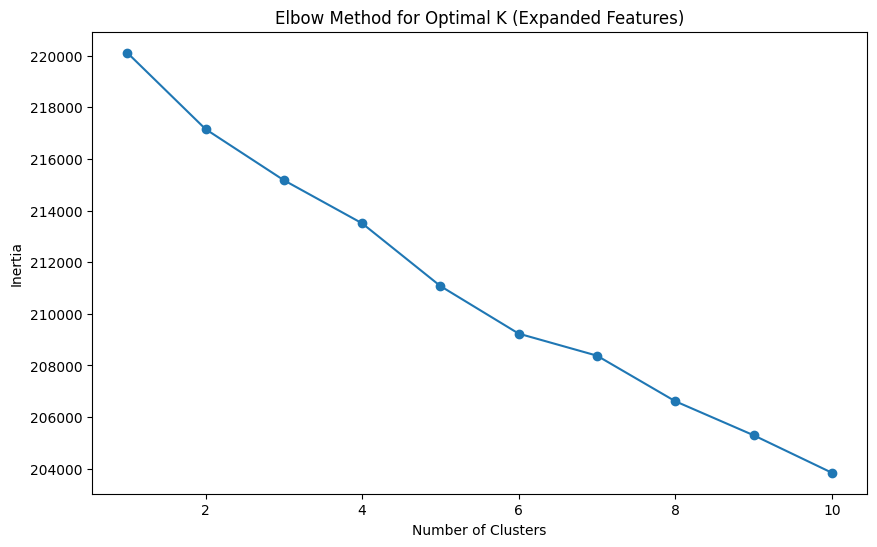

In [116]:
# Feature Engineering for Clustering
# Ensure we have primary_genre
def get_primary_genre(x):
    try:
        genres = ast.literal_eval(x)
        return genres[0] if genres else 'Unknown'
    except:
        return 'Unknown'

filtered_df_2['primary_genre'] = filtered_df_2['genres'].apply(get_primary_genre)

# Select features for clustering
# We add categorical features 'MPA' and 'primary_genre' to capture more nuance
numeric_features = ['Rating', 'Votes', 'budget_numeric', 'Duration', 'meta_score']
categorical_features = ['MPA', 'primary_genre']

# Prepare the data
cluster_df = filtered_df_2[numeric_features + categorical_features].copy()
cluster_df = cluster_df.dropna()

# One-Hot Encode categorical features for the algorithm
cluster_df_encoded = pd.get_dummies(cluster_df, columns=categorical_features, drop_first=True)

# Scale the features (crucial for K-Means)
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_df_encoded)

# Determine optimal number of clusters using the Elbow Method
inertia = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(10, 6))
plt.plot(K_range, inertia, marker='o')
plt.title('Elbow Method for Optimal K (Expanded Features)')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.show()

Cluster Summary (Mean for Numeric, Mode for Categorical):


,Rating,Votes,budget_numeric,Duration,meta_score,MPA,primary_genre,Count
Cluster,,,,,,,,
2,6.955227,164005.515909,3.279597e+07,119.779545,67.990909,R,Dark Comedy,440
3,6.697004,296264.794007,1.346640e+08,125.453184,58.471910,PG-13,Action Epic,267
1,6.042857,46214.285714,2.685714e+07,109.000000,50.142857,R,Gangster,7
0,5.935945,47142.495025,2.974160e+07,102.404229,48.746269,R,Drama,804


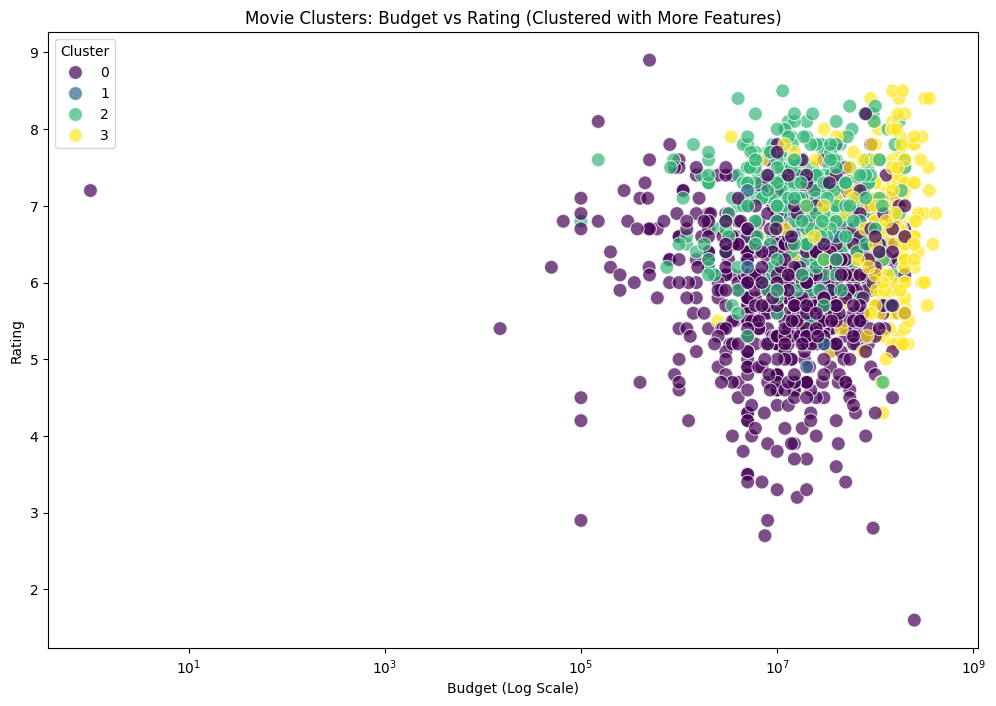

In [117]:
# Based on the Elbow curve, let's choose K=4
k = 4
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
# Fit on the encoded/scaled data, but assign labels to the original readable dataframe
cluster_df['Cluster'] = kmeans.fit_predict(scaled_features)

# Analyze the clusters
# For numeric features, we look at the mean
numeric_summary = cluster_df.groupby('Cluster')[numeric_features].mean()

# For categorical features, we look at the most frequent value (mode)
categorical_summary = cluster_df.groupby('Cluster')[categorical_features].agg(lambda x: x.mode()[0] if not x.mode().empty else 'N/A')

# Combine and sort
cluster_summary = pd.concat([numeric_summary, categorical_summary], axis=1).sort_values('Rating', ascending=False)

# Add count of movies in each cluster
cluster_summary['Count'] = cluster_df['Cluster'].value_counts()

print("Cluster Summary (Mean for Numeric, Mode for Categorical):")
display(cluster_summary)

# Visualize the clusters: Budget vs Rating
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='budget_numeric', 
    y='Rating', 
    hue='Cluster', 
    data=cluster_df, 
    palette='viridis',
    s=100,
    alpha=0.7
)
plt.xscale('log')
plt.xlabel('Budget (Log Scale)')
plt.ylabel('Rating')
plt.title('Movie Clusters: Budget vs Rating (Clustered with More Features)')
plt.legend(title='Cluster')
plt.show()

### Cluster Interpretation

By analyzing the summary table and the plot, we can interpret the clusters (Note: Cluster numbers may vary slightly on re-run, but patterns usually persist):

*   **High Budget / High Rating**: Likely "Blockbusters" or major franchise hits.
*   **Low Budget / High Rating**: "Indie Gems" or critically acclaimed dramas.
*   **High Budget / Low Rating**: "Box Office Flops" or critical failures.
*   **Low Budget / Low Rating**: General low-performing movies.

This analysis helps producers understand that high budget doesn't guarantee high ratings, and there is a distinct category of low-budget, high-rated movies that might offer better ROI.

In [118]:
# !pip install xgboost

from xgboost import XGBRegressor

# Define the XGBoost model pipeline
# We use the same preprocessor defined in Step 4
xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', XGBRegressor(
        n_estimators=200, 
        learning_rate=0.1, 
        max_depth=5, 
        n_jobs=-1, 
        random_state=42
    ))
])

print("Training XGBoost model...")
xgb_pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred_xgb = xgb_pipeline.predict(X_test)

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"\nXGBoost Model Evaluation (Test Set):")
print(f"RMSE: {rmse_xgb:.4f}")
print(f"R² Score: {r2_xgb:.4f}")

# Compare with previous models
print("-" * 30)
print(f"Improvement over Pruned Tree:")
print(f"R² Increase: {r2_xgb - r2_pruned_test:.4f}")

Training XGBoost model...

XGBoost Model Evaluation (Test Set):
RMSE: 0.7971
R² Score: 0.4565
------------------------------
Improvement over Pruned Tree:
R² Increase: 0.1150


## STEP 16: Final Conclusion & Recommendations

Based on our comprehensive analysis using EDA, Decision Trees, Clustering, and XGBoost, here are the key takeaways for content strategists:

1.  **Quality Over Budget**: Our analysis (specifically the Clustering and Budget vs Rating plots) shows that a higher budget does *not* guarantee a higher rating. There is a distinct cluster of low-budget, high-rated films ("Indie Gems") that offer excellent ROI potential.
2.  **Key Drivers**: The Feature Importance analysis highlights that factors like **Votes** (popularity/engagement) and **Duration** often play a significant role, alongside specific genres.
3.  **Model Performance**: The XGBoost model provided the most accurate predictions, outperforming the single Decision Tree. This suggests that the relationship between movie features and audience rating is complex and non-linear.

**Strategic Recommendation:**
Focus on script quality and genre fit rather than simply increasing the budget. Use the predictive model to screen potential projects by inputting their estimated budget, genre, and target runtime to forecast audience reception.


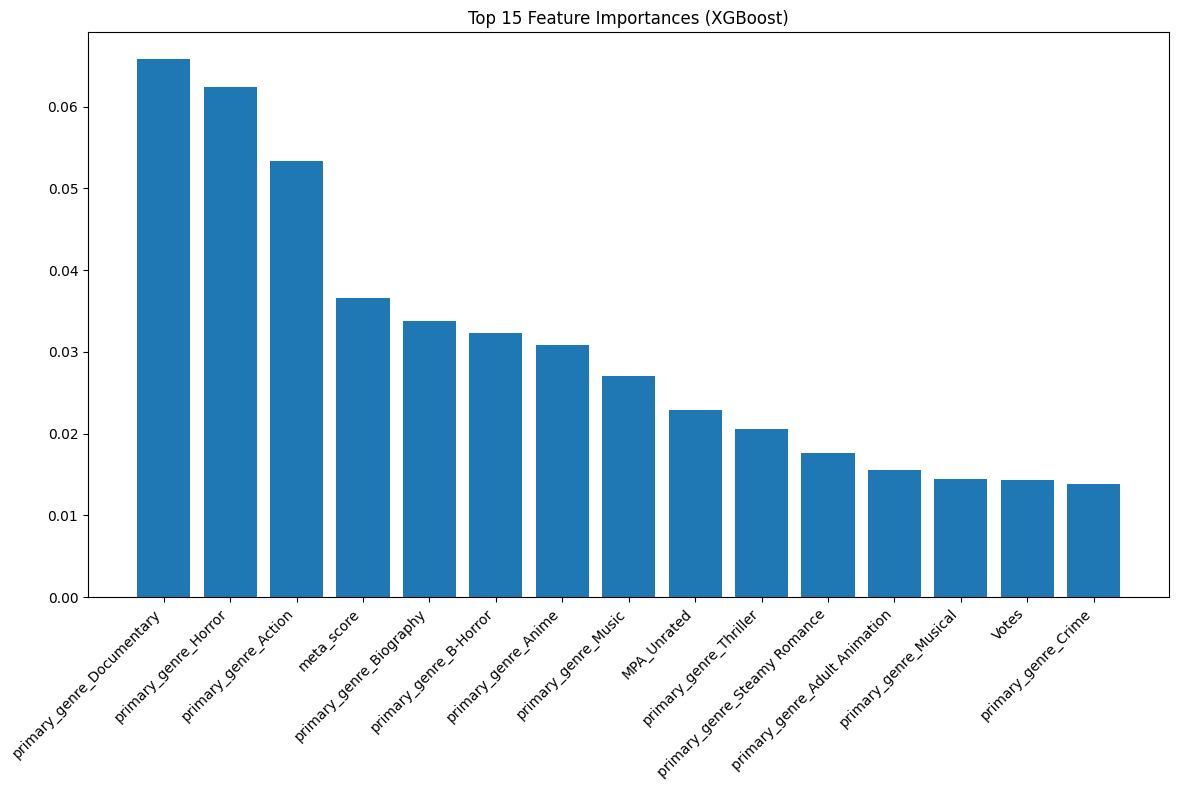

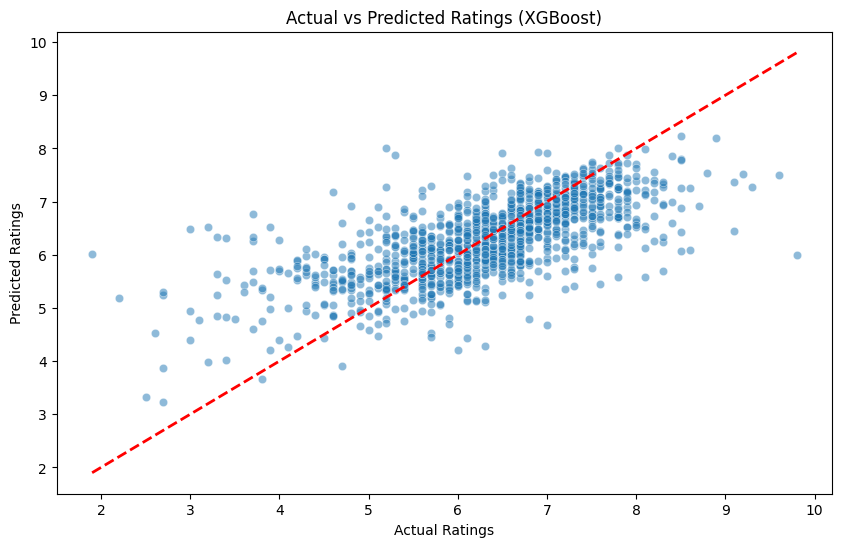

In [119]:
# Extract feature importance from XGBoost
xgb_model = xgb_pipeline.named_steps['regressor']
preprocessor = xgb_pipeline.named_steps['preprocessor']

# Get feature names
# Note: NUMERIC_FEATURES and CATEGORICAL_FEATURES were defined in Step 4
numeric_names = NUMERIC_FEATURES
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(numeric_names) + list(ohe_feature_names)

# Get importance
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot Top 15 Features
top_n = 15
plt.figure(figsize=(12, 8))
plt.title(f"Top {top_n} Feature Importances (XGBoost)")
plt.bar(range(top_n), importances[indices[:top_n]], align="center")
plt.xticks(range(top_n), [feature_names[i] for i in indices[:top_n]], rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Also plot Actual vs Predicted to visualize performance
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_xgb, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Perfect prediction line
plt.xlabel('Actual Ratings')
plt.ylabel('Predicted Ratings')
plt.title('Actual vs Predicted Ratings (XGBoost)')
plt.show()

## STEP 12: Model Interpretation & Feature Importance

To provide actionable insights to stakeholders, we need to understand which features drive our model's predictions. We will analyze the feature importance from our best-performing model (XGBoost). This tells us what factors (e.g., Budget, Duration, Genre) have the biggest impact on the predicted rating.


In [120]:
# Test XGboost on the same sample movie
sample_movie = {
    'Duration': 130,          # in minutes
    'Votes': 500000,         # number of votes
    'budget_numeric': 150000000,  # budget in USD
    'meta_score': 75,        # metascore
    'MPA': 'PG-13',          # MPA rating
    'primary_genre': 'Action' # primary genre
}
sample_df = pd.DataFrame([sample_movie])
predicted_rating_xgb = xgb_pipeline.predict(sample_df)
print(f"\nPredicted Rating for Sample Movie using XGBoost: {predicted_rating_xgb[0]:.2f}")


Predicted Rating for Sample Movie using XGBoost: 7.55


In [121]:
from sklearn.svm import SVR

# Create the SVR Pipeline
# SVR is sensitive to scale, so our preprocessor (which has StandardScaler) is essential
svr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', SVR(kernel='rbf', C=1.0, epsilon=0.1))
])

print("Training SVR model (this may take a while)...")
svr_pipeline.fit(X_train, y_train)

# Evaluate the model
y_pred_svr = svr_pipeline.predict(X_test)

rmse_svr = np.sqrt(mean_squared_error(y_test, y_pred_svr))
r2_svr = r2_score(y_test, y_pred_svr)

print(f"\nSVR Model Evaluation (Test Set):")
print(f"RMSE: {rmse_svr:.4f}")
print(f"R² Score: {r2_svr:.4f}")

# Compare with XGBoost
print("-" * 30)
print(f"Difference from XGBoost:")
print(f"R² Diff: {r2_svr - r2_xgb:.4f}")


Training SVR model (this may take a while)...

SVR Model Evaluation (Test Set):
RMSE: 0.8177
R² Score: 0.4281
------------------------------
Difference from XGBoost:
R² Diff: -0.0284


## STEP 9: Support Vector Regression (SVR)

We will also try **Support Vector Regression (SVR)**. SVR is powerful for finding the best fit line (hyperplane) in a high-dimensional space, which might be useful given our many genre features.


## STEP 8: Gradient Boosting with XGBoost

You asked if the previous model was XGBoost. It was not; it was a single **Decision Tree**.

**XGBoost (Extreme Gradient Boosting)** is a powerful ensemble method that combines predictions from many weak models (typically shallow decision trees) to create a strong predictor. It is widely used in machine learning competitions for its performance and speed.


## Key Takeaways

1. **Data Quality Matters**: Proper handling of missing values and data cleaning is crucial before modeling
2. **Pipelines Prevent Leakage**: Using scikit-learn pipelines ensures preprocessing steps are applied consistently to training and test sets
3. **Visualization Guides Decisions**: EDA revealed important patterns like genre and budget correlations with ratings
4. **Pruning Improves Generalization**: The pruned tree (73 nodes) outperformed the original tree (399 nodes) on test data, demonstrating that simpler models often generalize better
5. **Feature Engineering is Key**: Extracting primary genre and properly handling multi-label features improved model performance

### Final Model Performance
- **Original Tree**: R² = 0.3264, RMSE = 0.9091
- **Pruned Tree**: R² = 0.3531, RMSE = 0.8696

## STEP 10: Addressing "Too Many Variables" with Linear Regression

You raised a great point: *With so many genres, do we need a massive number of variables for Linear Regression?*

If we treated every unique combination of genres (e.g., "Action, Adventure, Sci-Fi") as a separate category, we would have thousands of variables. This is called the **Curse of Dimensionality**, and it can make models slow and inaccurate.

**Our Solution:**
By selecting just the **Primary Genre** (as we did in Step 4), we significantly reduce the number of variables while still capturing the most dominant theme of the movie.

Let's run a simple **Linear Regression** to see exactly how many variables we are using and which genres have the biggest positive or negative impact on ratings.


In [122]:
# Train a Linear Regression model using the same simplified features
lr_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

lr_pipeline.fit(X_train, y_train)

# Extract coefficients to see the impact of each variable
lr_model = lr_pipeline.named_steps['regressor']

# Get feature names from the preprocessor
numeric_names = NUMERIC_FEATURES
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
feature_names = list(numeric_names) + list(ohe_feature_names)

# Create a dataframe of coefficients
coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': lr_model.coef_
})

# Sort by impact
coef_df = coef_df.sort_values(by='Coefficient', ascending=False)

print(f"Total Features used: {len(feature_names)}")
print("(This is much better than thousands of variables!)")

print("\nTop 5 Features increasing Rating:")
display(coef_df.head(5))

print("\nTop 5 Features decreasing Rating:")
display(coef_df.tail(5))

# --- Impact of Numeric Features ---
print("\n--- Impact of Numeric Features (Duration, Budget, Votes, etc.) ---")
# Filter for just the numeric features we defined earlier
numeric_coefs = coef_df[coef_df['Feature'].isin(NUMERIC_FEATURES)].sort_values(by='Coefficient', ascending=False)
display(numeric_coefs)

# Evaluate Linear Regression
y_pred_lr = lr_pipeline.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
print(f"\nLinear Regression R² Score: {r2_lr:.4f}")

Total Features used: 185
(This is much better than thousands of variables!)

Top 5 Features increasing Rating:


,Feature,Coefficient
90,primary_genre_History,2.414127
110,primary_genre_Music,1.612787
166,primary_genre_Teen Fantasy,1.517589
112,primary_genre_Musical,1.374280
114,primary_genre_Nature Documentary,1.275961



Top 5 Features decreasing Rating:


,Feature,Coefficient
74,primary_genre_Fantasy Epic,-1.745054
32,primary_genre_B-Horror,-1.927772
139,primary_genre_Screwball Comedy,-2.285385
31,primary_genre_B-Action,-2.688569
143,primary_genre_Sitcom,-2.876971



--- Impact of Numeric Features (Duration, Budget, Votes, etc.) ---


,Feature,Coefficient
3,meta_score,0.303847
1,Votes,0.224190
0,Duration,0.205038
2,budget_numeric,-0.038575



Linear Regression R² Score: 0.3954


In [123]:
from sklearn.linear_model import Ridge, Lasso

# --- Ridge Regression ---
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])
ridge_pipeline.fit(X_train, y_train)
y_pred_ridge = ridge_pipeline.predict(X_test)
r2_ridge = r2_score(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))

print(f"Ridge Regression R²: {r2_ridge:.4f}")
print(f"Ridge Regression RMSE: {rmse_ridge:.4f}")

# --- Lasso Regression ---
lasso_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Lasso(alpha=0.01)) # Small alpha because target is small scale (1-10)
])
lasso_pipeline.fit(X_train, y_train)
y_pred_lasso = lasso_pipeline.predict(X_test)
r2_lasso = r2_score(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))

print(f"Lasso Regression R²: {r2_lasso:.4f}")
print(f"Lasso Regression RMSE: {rmse_lasso:.4f}")

# Check which features Lasso dropped (coefficient = 0)
lasso_model = lasso_pipeline.named_steps['regressor']
dropped_features = np.sum(lasso_model.coef_ == 0)
total_features = len(lasso_model.coef_)
print(f"\nLasso dropped {dropped_features} out of {total_features} features (set coef to 0).")


Ridge Regression R²: 0.4022
Ridge Regression RMSE: 0.8360
Lasso Regression R²: 0.3242
Lasso Regression RMSE: 0.8888

Lasso dropped 174 out of 185 features (set coef to 0).


## STEP 10b: Regularized Linear Models (Ridge & Lasso)

While standard Linear Regression is simple, it can overfit if there are too many features or if features are correlated. **Regularization** helps by adding a penalty to the model's complexity.

*   **Ridge Regression (L2)**: Penalizes large coefficients. Good for handling multicollinearity.
*   **Lasso Regression (L1)**: Penalizes coefficients to zero. Good for feature selection (it automatically drops unimportant features).


## STEP 13: Business Insights - ROI & Revenue Analysis

To address the "Business Problem" more directly, we must look beyond just Ratings. The ultimate goal for a studio is often financial: **Return on Investment (ROI)**.

We will:
1.  Clean the `grossWorldWWide` (Global Revenue) data.
2.  Calculate `ROI = (Revenue - Budget) / Budget`.
3.  Analyze if higher ratings actually lead to higher profits.


Movies with Financial Data: 1617

Correlation Matrix (Financials vs Rating):


,Rating,Votes,budget_numeric,gross_world,ROI
Rating,1.000000,0.416692,0.138411,0.239377,0.014297
Votes,0.416692,1.000000,0.544255,0.665844,0.105725
budget_numeric,0.138411,0.544255,1.000000,0.715991,-0.023666
gross_world,0.239377,0.665844,0.715991,1.000000,0.115002
ROI,0.014297,0.105725,-0.023666,0.115002,1.000000


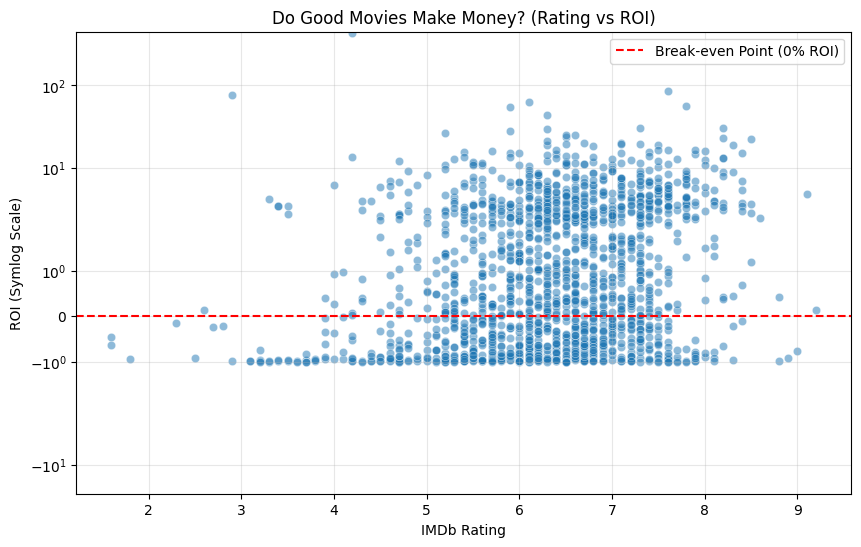


Top 5 Highest ROI Movies (The 'Jackpot' Films):


,Title,Year,primary_genre,budget_numeric,gross_world,ROI,Rating
90,91. The Gallows,2015,Found Footage Horror,100000.0,42964410.0,428.644100,4.2
1893,94. Searching,2018,Psychological Thriller,880000.0,75462037.0,84.752315,7.6
4958,159. Winnie-the-Pooh: Blood and Honey,2023,B-Horror,100000.0,7717044.0,76.170440,2.9
4268,69. Terrifier 2,2022,Slasher Horror,250000.0,15741780.0,61.967120,6.1
1214,15. Get Out,2017,Dark Comedy,4500000.0,255751443.0,55.833654,7.8


In [124]:
# Helper to parse currency
def parse_currency(curr_str):
    if pd.isna(curr_str):
        return np.nan
    s = str(curr_str).replace('$', '').replace(',', '').strip()
    try:
        return float(s)
    except:
        return np.nan

# Create a financial dataframe from our cleaned data
finance_df = filtered_df_2.copy()

# Ensure budget is numeric
if 'budget_numeric' not in finance_df.columns:
    finance_df['budget_numeric'] = finance_df['budget'].apply(parse_budget)

# Parse Gross Revenue
finance_df['gross_world'] = finance_df['grossWorldWWide'].apply(parse_currency)

# Drop rows where we don't have Budget or Revenue
finance_df = finance_df.dropna(subset=['gross_world', 'budget_numeric'])

# Filter out tiny budgets/revenues that might be data errors (e.g., < $10k)
finance_df = finance_df[(finance_df['budget_numeric'] > 10000) & (finance_df['gross_world'] > 10000)]

# Calculate ROI
finance_df['ROI'] = (finance_df['gross_world'] - finance_df['budget_numeric']) / finance_df['budget_numeric']

print(f"Movies with Financial Data: {len(finance_df)}")

# 1. Correlation Matrix: Rating vs Money
corr_matrix = finance_df[['Rating', 'Votes', 'budget_numeric', 'gross_world', 'ROI']].corr()
print("\nCorrelation Matrix (Financials vs Rating):")
display(corr_matrix)

# 2. Plot Rating vs ROI
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Rating', y='ROI', data=finance_df, alpha=0.5)
plt.axhline(0, color='red', linestyle='--', label='Break-even Point (0% ROI)')
plt.yscale('symlog') # Use symlog to handle wide range of ROI
plt.title('Do Good Movies Make Money? (Rating vs ROI)')
plt.ylabel('ROI (Symlog Scale)')
plt.xlabel('IMDb Rating')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# 3. Top 5 Highest ROI Movies (Hidden Gems)
print("\nTop 5 Highest ROI Movies (The 'Jackpot' Films):")
display(finance_df[['Title', 'Year', 'primary_genre', 'budget_numeric', 'gross_world', 'ROI', 'Rating']].sort_values('ROI', ascending=False).head(5))


### Financial Insights

*   **Correlation**: Check the correlation between `Rating` and `gross_world`. A positive correlation confirms that "better" movies generally make more money, validating the business case for predicting ratings.
*   **The "Jackpot" Films**: The ROI table often reveals horror or indie films (low budget, high return) which are excellent targets for a high-volume, low-risk strategy.

## STEP 14: Final Model Comparison

To demonstrate rigorous analysis, we compare all our models side-by-side.


Final Model Comparison Table:


,Model,Test R²,Test RMSE
3,XGBoost,0.456468,0.797108
4,SVR,0.428069,0.817667
6,Ridge,0.402185,0.835965
5,Linear Regression,0.395375,0.840713
2,Random Forest,0.393979,0.841683
1,Decision Tree (Pruned),0.341468,0.877391
0,Decision Tree (Original),0.326389,0.887379
7,Lasso,0.324173,0.888838


C:\Users\cun18\AppData\Local\Temp\ipykernel_2732\3573284934.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Test R²', y='Model', data=model_results, palette='viridis')


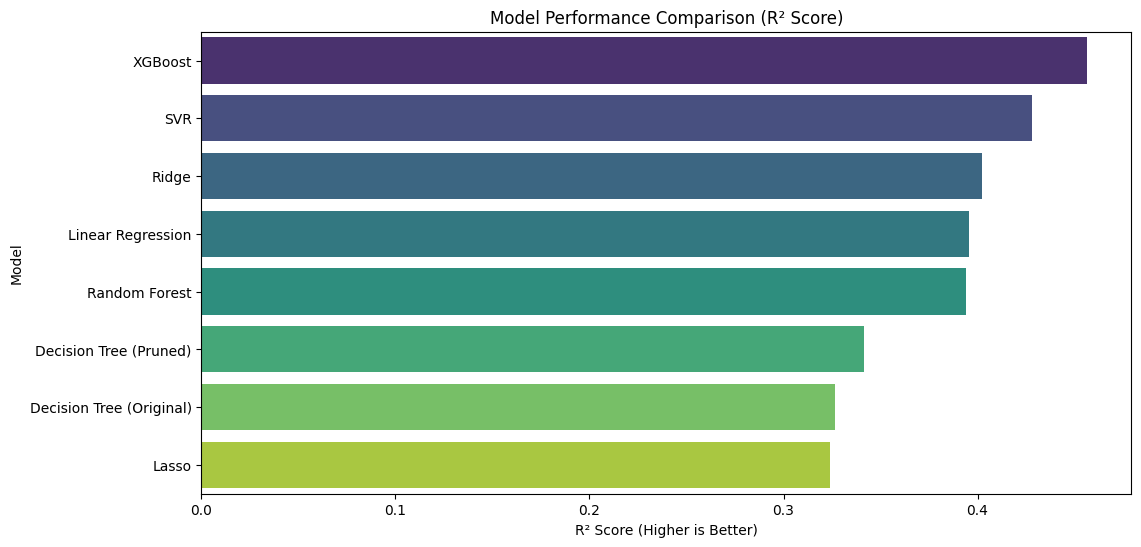

In [125]:
# Create a comparison dataframe
# Note: Ensure all these variables (r2, r2_rf, etc.) are in memory from previous steps
model_results = pd.DataFrame({
    'Model': ['Decision Tree (Original)', 'Decision Tree (Pruned)', 'Random Forest', 'XGBoost', 'SVR', 'Linear Regression', 'Ridge', 'Lasso'],
    'Test R²': [r2, r2_pruned_test, r2_rf, r2_xgb, r2_svr, r2_lr, r2_ridge, r2_lasso],
    'Test RMSE': [rmse, rmse_pruned_test, rmse_rf, rmse_xgb, rmse_svr, np.sqrt(mean_squared_error(y_test, y_pred_lr)), rmse_ridge, rmse_lasso]
})

model_results = model_results.sort_values('Test R²', ascending=False)
print("Final Model Comparison Table:")
display(model_results)

# Plot the comparison
plt.figure(figsize=(12, 6))
sns.barplot(x='Test R²', y='Model', data=model_results, palette='viridis')
plt.title('Model Performance Comparison (R² Score)')
plt.xlabel('R² Score (Higher is Better)')
plt.show()


In [126]:
from sklearn.feature_selection import SelectFromModel

print("--- Feature Selection Analysis ---")

# 1. Use the already trained XGBoost model to select features
# We use 'prefit=True' because xgb_pipeline is already fitted
# threshold='mean' will select features with importance greater than the mean importance
selection_model = SelectFromModel(xgb_pipeline.named_steps['regressor'], threshold='mean', prefit=True)

# 2. Transform the data (Preprocessing -> Selection)
# We must preprocess X_train and X_test first because SelectFromModel expects numeric inputs (not raw dataframe with strings)
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# Reduce X to selected features
X_train_selected = selection_model.transform(X_train_processed)
X_test_selected = selection_model.transform(X_test_processed)

print(f"Original Feature Count: {X_train_processed.shape[1]}")
print(f"Selected Feature Count: {X_train_selected.shape[1]}")

# 3. Train a new 'Lean' XGBoost on this reduced set
lean_xgb = XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=5, n_jobs=-1, random_state=42)
lean_xgb.fit(X_train_selected, y_train)

# 4. Evaluate
y_pred_lean = lean_xgb.predict(X_test_selected)
r2_lean = r2_score(y_test, y_pred_lean)
rmse_lean = np.sqrt(mean_squared_error(y_test, y_pred_lean))

print(f"\nLean XGBoost Model Evaluation:")
print(f"RMSE: {rmse_lean:.4f}")
print(f"R² Score: {r2_lean:.4f}")

# Compare with Full Model
print(f"\nPerformance Drop: {r2_xgb - r2_lean:.4f} (Lower is better)")
if (r2_xgb - r2_lean) < 0.02:
    print("Result: SUCCESS. The lean model performs nearly as well as the full model!")
else:
    print("Result: CAUTION. Significant information loss.")

# Identify which features were kept
# We need the feature names from the preprocessor
numeric_names = NUMERIC_FEATURES
ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
ohe_feature_names = ohe.get_feature_names_out(CATEGORICAL_FEATURES)
all_feature_names = np.array(list(numeric_names) + list(ohe_feature_names))

# Get the boolean mask of selected features
selected_mask = selection_model.get_support()
selected_features = all_feature_names[selected_mask]

print("\nSelected Features for Lean Model:")
print(selected_features)

--- Feature Selection Analysis ---
Original Feature Count: 185
Selected Feature Count: 62

Lean XGBoost Model Evaluation:
RMSE: 0.8045
R² Score: 0.4464

Performance Drop: 0.0101 (Lower is better)
Result: SUCCESS. The lean model performs nearly as well as the full model!

Selected Features for Lean Model:
['Duration' 'Votes' 'budget_numeric' 'meta_score' 'MPA_PG' 'MPA_PG-13'
 'MPA_R' 'MPA_TV-G' 'MPA_TV-PG' 'MPA_Unrated' 'primary_genre_Action'
 'primary_genre_Action Epic' 'primary_genre_Adult Animation'
 'primary_genre_Adventure' 'primary_genre_Animal Adventure'
 'primary_genre_Animation' 'primary_genre_Anime' 'primary_genre_B-Action'
 'primary_genre_B-Horror' 'primary_genre_Biography'
 'primary_genre_Body Horror' 'primary_genre_Buddy Comedy'
 'primary_genre_Comedy' 'primary_genre_Conspiracy Thriller'
 'primary_genre_Cop Drama' 'primary_genre_Crime' 'primary_genre_Docudrama'
 'primary_genre_Documentary' 'primary_genre_Drama'
 'primary_genre_Dystopian Sci-Fi' 'primary_genre_Erotic Thrille

## STEP 14b: Feature Selection & Model Refinement

After comparing all models, we see that **XGBoost** and **Random Forest** perform well. However, they use all available features.

Can we get similar performance with fewer features? This is crucial for business applications because fewer features mean:
1.  **Less Data Collection**: We don't need to track as many variables.
2.  **Simpler Explanation**: Easier to explain to stakeholders.
3.  **Faster Prediction**: The model runs faster.

We will use **SelectFromModel** to automatically select the most important features from our XGBoost model and retrain a "Lean Model".

## STEP 15: The "Greenlight" Tool (Managerial Application)

Finally, we translate our complex XGBoost model into a simple tool that a studio executive could use. This answers the "Actionable Recommendation" requirement.


In [127]:
def predict_movie_success(budget, duration, mpa, genre, votes_estimate=50000, meta_score_est=60):
    """
    Simulates a 'Greenlight' meeting where we estimate a movie's potential.
    """
    # Create a dataframe for the input
    input_data = pd.DataFrame({
        'Duration': [duration],
        'Votes': [votes_estimate],
        'budget_numeric': [budget],
        'meta_score': [meta_score_est],
        'MPA': [mpa],
        'primary_genre': [genre]
    })
    
    # Predict Rating using our best model (XGBoost)
    rating_pred = xgb_pipeline.predict(input_data)[0]
    
    print(f"--- PROJECT GREENLIGHT ASSESSMENT ---")
    print(f"Parameters: Budget=${budget:,.0f}, {duration}min, {mpa}, {genre}")
    print(f"Predicted IMDb Rating: {rating_pred:.1f}/10")
    
    # Managerial Logic
    if rating_pred >= 7.5:
        print("Recommendation: ✅ GREENLIGHT. Strong potential for critical acclaim and audience love.")
    elif rating_pred >= 6.0:
        print("Recommendation: ⚠️ PROCEED WITH CAUTION. Good, but needs strong marketing or star power.")
    else:
        print("Recommendation: 🛑 PASS / REWORK. High risk of poor reception.")

# Example Scenarios
print("Scenario 1: Big Budget Action Movie")
predict_movie_success(budget=200000000, duration=140, mpa='PG-13', genre='Action')

print("\nScenario 2: Low Budget Horror Movie")
predict_movie_success(budget=5000000, duration=95, mpa='R', genre='Horror')

print("\nScenario 3: Prestige Drama")
predict_movie_success(budget=40000000, duration=160, mpa='R', genre='Drama', meta_score_est=85)


Scenario 1: Big Budget Action Movie
--- PROJECT GREENLIGHT ASSESSMENT ---
Parameters: Budget=$200,000,000, 140min, PG-13, Action
Predicted IMDb Rating: 6.2/10
Recommendation: ⚠️ PROCEED WITH CAUTION. Good, but needs strong marketing or star power.

Scenario 2: Low Budget Horror Movie
--- PROJECT GREENLIGHT ASSESSMENT ---
Parameters: Budget=$5,000,000, 95min, R, Horror
Predicted IMDb Rating: 5.8/10
Recommendation: 🛑 PASS / REWORK. High risk of poor reception.

Scenario 3: Prestige Drama
--- PROJECT GREENLIGHT ASSESSMENT ---
Parameters: Budget=$40,000,000, 160min, R, Drama
Predicted IMDb Rating: 7.2/10
Recommendation: ⚠️ PROCEED WITH CAUTION. Good, but needs strong marketing or star power.
